In [1]:
import numpy as np

from mpi4py import MPI
from petsc4py import PETSc

import ufl
from basix.ufl import element, mixed_element
from dolfinx import mesh, fem
from dolfinx.fem.petsc import LinearProblem

import matplotlib.pyplot as plt
import seaborn as sns

from dolfinx import geometry

In [2]:
def solve_mixed_2d(n=16, degree=1, delta1=-0.5, delta2=0.0, delta3=0.0):
    comm = MPI.COMM_WORLD

    msh = mesh.create_unit_square(
        comm,
        n,
        n,
        cell_type=mesh.CellType.triangle
    )

    x = ufl.SpatialCoordinate(msh)

    p_exact = ufl.sin(np.pi * x[0]) * ufl.sin(np.pi * x[1])

    u_exact = ufl.as_vector((
        -np.pi * ufl.cos(np.pi * x[0]) * ufl.sin(np.pi * x[1]),
        -np.pi * ufl.sin(np.pi * x[0]) * ufl.cos(np.pi * x[1])
    ))

    f = 2.0 * np.pi**2 * ufl.sin(np.pi * x[0]) * ufl.sin(np.pi * x[1])

    U_el = element(
        "Lagrange",
        msh.basix_cell(),
        degree,
        shape=(msh.geometry.dim,)
    )

    P_el = element(
        "Lagrange",
        msh.basix_cell(),
        degree
    )

    W_el = mixed_element([U_el, P_el])
    W = fem.functionspace(msh, W_el)

    w = ufl.TrialFunction(W)
    z = ufl.TestFunction(W)

    u, p = ufl.split(w)
    v, q = ufl.split(z)

    dx = ufl.Measure("dx", domain=msh)

    a = (
        ufl.dot(u, v) * dx
        - p * ufl.div(v) * dx
        - q * ufl.div(u) * dx
    )

    L = -f * q * dx

    if delta1 != 0.0:
        a += delta1 * ufl.dot(u + ufl.grad(p), v + ufl.grad(q)) * dx

    if delta2 != 0.0:
        a += delta2 * ufl.div(u) * ufl.div(v) * dx
        L += delta2 * f * ufl.div(v) * dx

    if delta3 != 0.0:
        a += delta3 * ufl.curl(u) * ufl.curl(v) * dx

    problem = LinearProblem(
        a,
        L,
        bcs=[],
        petsc_options_prefix=f"mixed2d_n{n}_k{degree}_",
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu"
        }
    )

    wh = problem.solve()

    uh = wh.sub(0).collapse()
    ph = wh.sub(1).collapse()

    error_u_local = fem.assemble_scalar(
        fem.form(ufl.inner(uh - u_exact, uh - u_exact) * dx)
    )

    error_p_local = fem.assemble_scalar(
        fem.form((ph - p_exact) ** 2 * dx)
    )

    error_u = np.sqrt(comm.allreduce(error_u_local, op=MPI.SUM))
    error_p = np.sqrt(comm.allreduce(error_p_local, op=MPI.SUM))

    return msh, uh, ph, error_u, error_p

In [3]:
msh, uh, ph, error_u, error_p = solve_mixed_2d(
    n=128,
    degree=1,
    delta1=-0.5,
    delta2=0.0,
    delta3=0.0
)

print(f"Erro L2 de u: {error_u:.6e}")
print(f"Erro L2 de p: {error_p:.6e}")

Erro L2 de u: 2.525466e-04
Erro L2 de p: 4.752579e-05


In [4]:
def convergence_study_2d(
    degrees=[1, 2, 3, 4],
    ns=[8, 16, 32, 64],
    delta1=-0.5,
    delta2=0.0,
    delta3=0.0
):
    results = {}

    for degree in degrees:
        print(f"\n===== k = {degree} =====")
        print(
            f"{'n':<8} | {'h':<12} | {'erro_u':<14} | {'taxa_u':<10} | "
            f"{'erro_p':<14} | {'taxa_p':<10}"
        )
        print("-" * 86)

        results[degree] = []

        previous_error_u = None
        previous_error_p = None
        previous_h = None

        for n in ns:
            h = 1.0 / n

            msh, uh, ph, error_u, error_p = solve_mixed_2d(
                n=n,
                degree=degree,
                delta1=delta1,
                delta2=delta2,
                delta3=delta3
            )

            if previous_error_u is None:
                rate_u = None
                rate_p = None
            else:
                rate_u = np.log(previous_error_u / error_u) / np.log(previous_h / h)
                rate_p = np.log(previous_error_p / error_p) / np.log(previous_h / h)

            results[degree].append({
                "n": n,
                "h": h,
                "error_u": error_u,
                "rate_u": rate_u,
                "error_p": error_p,
                "rate_p": rate_p
            })

            rate_u_str = "-" if rate_u is None else f"{rate_u:.4f}"
            rate_p_str = "-" if rate_p is None else f"{rate_p:.4f}"

            print(
                f"{n:<8} | {h:<12.4e} | {error_u:<14.6e} | {rate_u_str:<10} | "
                f"{error_p:<14.6e} | {rate_p_str:<10}"
            )

            previous_error_u = error_u
            previous_error_p = error_p
            previous_h = h

    return results

In [5]:
results_full = convergence_study_2d(
    degrees=[1, 2, 3, 4],
    ns=[8, 16, 32, 64],
    delta1=-0.5,
    delta2=0.5,
    delta3=0.5
)


===== k = 1 =====
n        | h            | erro_u         | taxa_u     | erro_p         | taxa_p    
--------------------------------------------------------------------------------------
8        | 1.2500e-01   | 4.017668e-01   | -          | 5.455502e-02   | -         
16       | 6.2500e-02   | 1.933521e-01   | 1.0551     | 2.639968e-02   | 1.0472    
32       | 3.1250e-02   | 6.375675e-02   | 1.6006     | 8.615105e-03   | 1.6156    
64       | 1.5625e-02   | 1.785300e-02   | 1.8364     | 2.313516e-03   | 1.8968    

===== k = 2 =====
n        | h            | erro_u         | taxa_u     | erro_p         | taxa_p    
--------------------------------------------------------------------------------------
8        | 1.2500e-01   | 1.111050e-02   | -          | 9.873643e-04   | -         
16       | 6.2500e-02   | 1.632417e-03   | 2.7668     | 1.021639e-04   | 3.2727    
32       | 3.1250e-02   | 2.540491e-04   | 2.6838     | 1.128742e-05   | 3.1781    
64       | 1.5625e-02   | 3.9919

In [6]:
results_no_stab = convergence_study_2d(
    degrees=[1, 2, 3, 4],
    ns=[8, 16, 32, 64],
    delta1=0.0,
    delta2=0.0,
    delta3=0.0
)


===== k = 1 =====
n        | h            | erro_u         | taxa_u     | erro_p         | taxa_p    
--------------------------------------------------------------------------------------
8        | 1.2500e-01   | inf            | -          | inf            | -         
16       | 6.2500e-02   | inf            | nan        | inf            | nan       
32       | 3.1250e-02   | inf            | nan        | inf            | nan       


/tmp/ipykernel_42421/3755849462.py:39: RuntimeWarning: invalid value encountered in scalar divide
  rate_u = np.log(previous_error_u / error_u) / np.log(previous_h / h)
/tmp/ipykernel_42421/3755849462.py:40: RuntimeWarning: invalid value encountered in scalar divide
  rate_p = np.log(previous_error_p / error_p) / np.log(previous_h / h)


64       | 1.5625e-02   | inf            | nan        | inf            | nan       

===== k = 2 =====
n        | h            | erro_u         | taxa_u     | erro_p         | taxa_p    
--------------------------------------------------------------------------------------
8        | 1.2500e-01   | nan            | -          | nan            | -         
16       | 6.2500e-02   | nan            | nan        | nan            | nan       
32       | 3.1250e-02   | nan            | nan        | nan            | nan       
64       | 1.5625e-02   | nan            | nan        | nan            | nan       

===== k = 3 =====
n        | h            | erro_u         | taxa_u     | erro_p         | taxa_p    
--------------------------------------------------------------------------------------
8        | 1.2500e-01   | nan            | -          | nan            | -         
16       | 6.2500e-02   | nan            | nan        | nan            | nan       
32       | 3.1250e-02   | nan   

In [7]:
def sample_function_on_grid(msh, func, nx=100, ny=100):
    """
    Amostra uma Function do FEniCSx em uma grade regular 2D.

    Retorna:
        X, Y, values

    onde:
        - values tem shape (ny, nx) para escalar
        - values tem shape (ny, nx, ncomp) para vetorial
    """
    coords = msh.geometry.x
    xmin, ymin = coords[:, 0].min(), coords[:, 1].min()
    xmax, ymax = coords[:, 0].max(), coords[:, 1].max()

    xs = np.linspace(xmin, xmax, nx)
    ys = np.linspace(ymin, ymax, ny)

    X, Y = np.meshgrid(xs, ys, indexing="xy")

    points2d = np.column_stack([X.ravel(), Y.ravel()])

    points = np.zeros((points2d.shape[0], 3), dtype=np.float64)
    points[:, :2] = points2d

    tree = geometry.bb_tree(msh, msh.topology.dim)
    cell_candidates = geometry.compute_collisions_points(tree, points)
    cell_collisions = geometry.compute_colliding_cells(msh, cell_candidates, points)

    valid_points = []
    valid_cells = []
    valid_indices = []

    for i in range(points.shape[0]):
        cells = cell_collisions.links(i)

        if len(cells) > 0:
            valid_points.append(points[i])
            valid_cells.append(cells[0])
            valid_indices.append(i)

    valid_points = np.array(valid_points, dtype=np.float64)
    valid_cells = np.array(valid_cells, dtype=np.int32)
    valid_indices = np.array(valid_indices, dtype=np.int32)

    values_eval = func.eval(valid_points, valid_cells)
    values_eval = np.asarray(values_eval)

    # Caso escalar: FEniCSx pode retornar shape (N,) ou (N, 1)
    if values_eval.ndim == 1 or values_eval.shape[1] == 1:
        values_all = np.full(points.shape[0], np.nan, dtype=np.float64)

        if values_eval.ndim == 2:
            values_eval = values_eval[:, 0]

        values_all[valid_indices] = values_eval
        values_all = values_all.reshape(ny, nx)

    # Caso vetorial: shape (N, ncomp)
    else:
        ncomp = values_eval.shape[1]

        values_all = np.full((points.shape[0], ncomp), np.nan, dtype=np.float64)
        values_all[valid_indices, :] = values_eval
        values_all = values_all.reshape(ny, nx, ncomp)

    return X, Y, values_all

def plot_mixed_solution_seaborn(
    msh,
    uh,
    ph,
    nx=100,
    ny=100,
    cmap="viridis",
    figsize=(20, 5)
):
    """
    Plota os resultados aproximados ph e uh com seaborn.

    Mostra:
        1) ph
        2) uh_x
        3) uh_y
        4) |uh|
    """
    sns.set_theme(style="white")

    _, _, p_vals = sample_function_on_grid(msh, ph, nx=nx, ny=ny)
    _, _, u_vals = sample_function_on_grid(msh, uh, nx=nx, ny=ny)

    if u_vals.ndim != 3 or u_vals.shape[2] < 2:
        raise ValueError("uh precisa ser uma função vetorial 2D.")

    ux = u_vals[:, :, 0]
    uy = u_vals[:, :, 1]
    umag = np.sqrt(ux**2 + uy**2)

    fig, axes = plt.subplots(1, 4, figsize=figsize, constrained_layout=True)

    plots = [
        (p_vals, r"$p_h$"),
        (ux, r"$u_{h,x}$"),
        (uy, r"$u_{h,y}$"),
        (umag, r"$\|\mathbf{u}_h\|$")
    ]

    for ax, (data, title) in zip(axes, plots):
        sns.heatmap(
            data,
            ax=ax,
            cmap=cmap,
            cbar=True,
            xticklabels=False,
            yticklabels=False,
            square=True
        )
        ax.set_title(title, fontsize=14)
        ax.invert_yaxis()

    plt.show()

In [8]:
msh, uh, ph, error_u, error_p = solve_mixed_2d(
    n=128,
    degree=4,
    delta1=-0.5,
    delta2=0.0,
    delta3=0.0
)

print(f"Erro L2 de u: {error_u:.6e}")
print(f"Erro L2 de p: {error_p:.6e}")

Erro L2 de u: 9.101248e-10
Erro L2 de p: 8.268466e-13


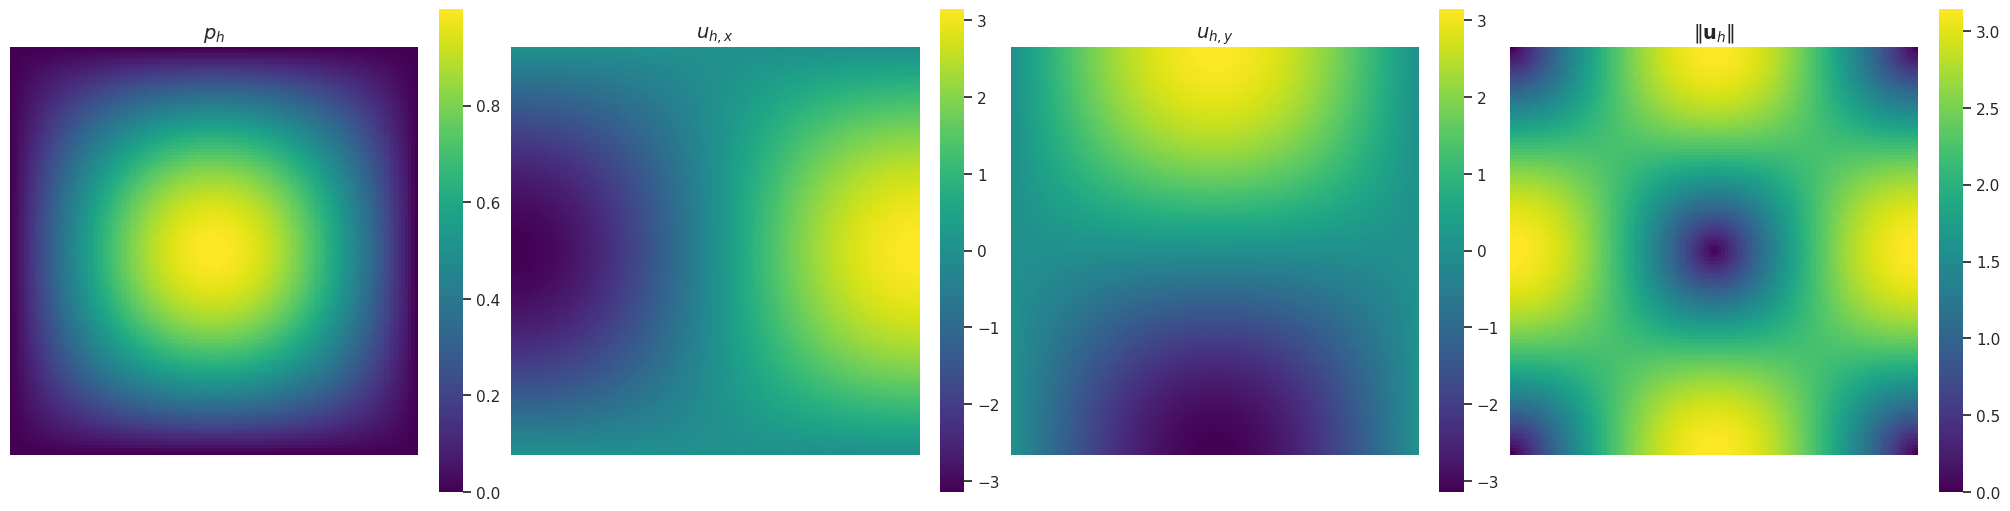

In [9]:
plot_mixed_solution_seaborn(msh, uh, ph, nx=120, ny=120)

In [10]:
msh, uh, ph, error_u, error_p = solve_mixed_2d(
    n=128,
    degree=4,
    delta1=-0.5,
    delta2=0.5,
    delta3=0.5
)
print(f"Erro L2 de u: {error_u:.6e}")
print(f"Erro L2 de p: {error_p:.6e}")

Erro L2 de u: 1.021394e-10
Erro L2 de p: 1.258912e-11


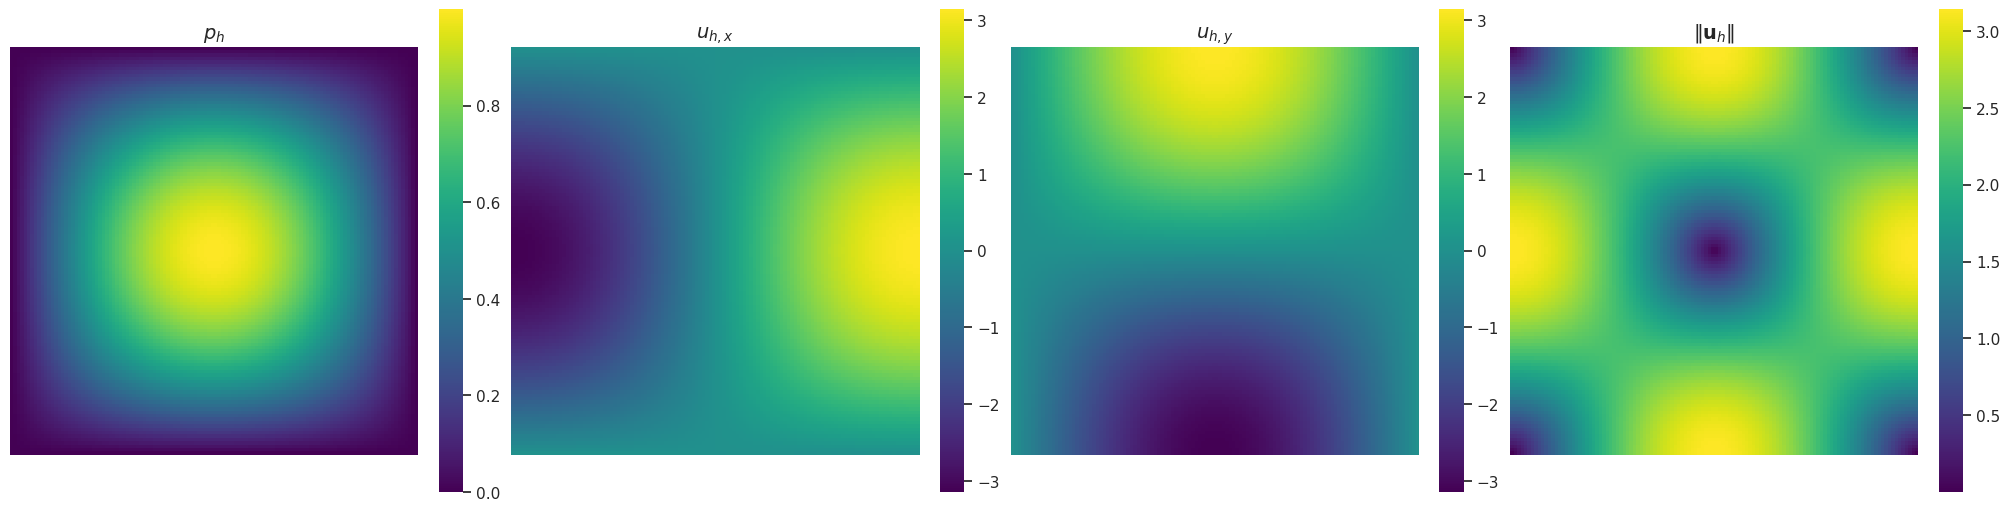

In [11]:
plot_mixed_solution_seaborn(msh, uh, ph, nx=120, ny=120)

In [12]:
results_full = convergence_study_2d(
    degrees=[1, 2],
    ns=[64, 128, 256, 512],
    delta1=-0.5,
    delta2=0.0,
    delta3=0.0
)


===== k = 1 =====
n        | h            | erro_u         | taxa_u     | erro_p         | taxa_p    
--------------------------------------------------------------------------------------
64       | 1.5625e-02   | 1.009581e-03   | -          | 1.900813e-04   | -         
128      | 7.8125e-03   | 2.525466e-04   | 1.9991     | 4.752579e-05   | 1.9998    
256      | 3.9062e-03   | 6.315668e-05   | 1.9995     | 1.188173e-05   | 2.0000    
512      | 1.9531e-03   | 1.579178e-05   | 1.9998     | 2.970446e-06   | 2.0000    

===== k = 2 =====
n        | h            | erro_u         | taxa_u     | erro_p         | taxa_p    
--------------------------------------------------------------------------------------
64       | 1.5625e-02   | 4.320568e-04   | -          | 1.062086e-06   | -         
128      | 7.8125e-03   | 1.098784e-04   | 1.9753     | 1.336156e-07   | 2.9907    
256      | 3.9062e-03   | 2.768179e-05   | 1.9889     | 1.675351e-08   | 2.9956    
512      | 1.9531e-03   | 6.9455

In [13]:
results_full = convergence_study_2d(
    degrees=[1, 2],
    ns=[64, 128, 256, 512],
    delta1=-0.5,
    delta2=0.5,
    delta3=0.5
)


===== k = 1 =====
n        | h            | erro_u         | taxa_u     | erro_p         | taxa_p    
--------------------------------------------------------------------------------------
64       | 1.5625e-02   | 1.785300e-02   | -          | 2.313516e-03   | -         
128      | 7.8125e-03   | 4.830920e-03   | 1.8858     | 5.855934e-04   | 1.9821    
256      | 3.9062e-03   | 1.287957e-03   | 1.9072     | 1.459655e-04   | 2.0043    
512      | 1.9531e-03   | 3.404917e-04   | 1.9194     | 3.626862e-05   | 2.0088    

===== k = 2 =====
n        | h            | erro_u         | taxa_u     | erro_p         | taxa_p    
--------------------------------------------------------------------------------------
64       | 1.5625e-02   | 3.991973e-05   | -          | 1.290737e-06   | -         
128      | 7.8125e-03   | 6.286549e-06   | 2.6668     | 1.517529e-07   | 3.0884    
256      | 3.9062e-03   | 9.907492e-07   | 2.6657     | 1.819777e-08   | 3.0599    
512      | 1.9531e-03   | 1.5618

In [14]:
results_full = convergence_study_2d(
    degrees=[1, 2],
    ns=[64, 128, 256, 512],
    delta1=-0.5,
    delta2=0.5,
    delta3=0.0
)


===== k = 1 =====
n        | h            | erro_u         | taxa_u     | erro_p         | taxa_p    
--------------------------------------------------------------------------------------
64       | 1.5625e-02   | 9.330156e-03   | -          | 5.187201e-04   | -         
128      | 7.8125e-03   | 3.692604e-03   | 1.3373     | 1.345344e-04   | 1.9470    
256      | 3.9062e-03   | 1.409736e-03   | 1.3892     | 3.437320e-05   | 1.9686    
512      | 1.9531e-03   | 5.233796e-04   | 1.4295     | 8.710687e-06   | 1.9804    

===== k = 2 =====
n        | h            | erro_u         | taxa_u     | erro_p         | taxa_p    
--------------------------------------------------------------------------------------
64       | 1.5625e-02   | 4.317559e-05   | -          | 1.067840e-06   | -         
128      | 7.8125e-03   | 1.070829e-05   | 2.0115     | 1.339668e-07   | 2.9947    
256      | 3.9062e-03   | 2.671777e-06   | 2.0029     | 1.677513e-08   | 2.9975    
512      | 1.9531e-03   | 6.6762

In [15]:
results_full = convergence_study_2d(
    degrees=[1, 2],
    ns=[64, 128, 256, 512],
    delta1=0.0,
    delta2=0.0,
    delta3=0.0
)


===== k = 1 =====
n        | h            | erro_u         | taxa_u     | erro_p         | taxa_p    
--------------------------------------------------------------------------------------
64       | 1.5625e-02   | inf            | -          | inf            | -         


/tmp/ipykernel_42421/3755849462.py:39: RuntimeWarning: invalid value encountered in scalar divide
  rate_u = np.log(previous_error_u / error_u) / np.log(previous_h / h)
/tmp/ipykernel_42421/3755849462.py:40: RuntimeWarning: invalid value encountered in scalar divide
  rate_p = np.log(previous_error_p / error_p) / np.log(previous_h / h)


128      | 7.8125e-03   | inf            | nan        | inf            | nan       
256      | 3.9062e-03   | inf            | nan        | inf            | nan       
512      | 1.9531e-03   | inf            | nan        | inf            | nan       

===== k = 2 =====
n        | h            | erro_u         | taxa_u     | erro_p         | taxa_p    
--------------------------------------------------------------------------------------
64       | 1.5625e-02   | nan            | -          | nan            | -         
128      | 7.8125e-03   | nan            | nan        | nan            | nan       
256      | 3.9062e-03   | nan            | nan        | nan            | nan       
512      | 1.9531e-03   | nan            | nan        | nan            | nan       
